# 🫘 NephroScan AI — Universal Model Evaluator

Test your trained model on **any dataset** by changing the config in Cell 2.

Supports:
- Standard folders: `stone/` and `no_stone/`
- YOLO datasets: `images/` + `labels/` (auto-converts to binary)
- Stone-only datasets (sensitivity test)
- Mixed external + original no_stone

**Outputs:** Sensitivity, Specificity, AUC, F2, Confusion Matrix, ROC Curve, per-image confidence distribution

## Cell 1 — Imports & Setup

In [1]:
import os, sys, torch, cv2, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from tqdm.notebook import tqdm
from sklearn.metrics import (
    roc_auc_score, roc_curve, confusion_matrix,
    ConfusionMatrixDisplay, fbeta_score, classification_report
)

os.chdir('/Users/devaguru/Kidney Stone CNN/kidney-stone-cnn')
sys.path.insert(0, '.')

from src.models.efficientnet import KidneyStoneClassifier
from src.data.augmentations import get_val_transforms

device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f'Device: {device}')
print('Ready.')

Device: mps
Ready.


## Cell 2 — ⚙️ CONFIG — Change This for Each Dataset

In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# DATASET MODE — choose one:
#   'classification' — folders named stone/ and no_stone/
#   'yolo'           — folders named images/ and labels/ (YOLO format)
#   'stone_only'     — only stone images, measures sensitivity only
#   'mixed'          — external stone images + original no_stone images
# ─────────────────────────────────────────────────────────────────────────────
DATASET_MODE = 'mixed'

# ── For mode = 'classification' ───────────────────────────────────────────────
# Folder with stone/ and no_stone/ subfolders
CLASSIFICATION_DIR = 'data/processed/test'

# ── For mode = 'yolo' ─────────────────────────────────────────────────────────
# Folder with images/ and labels/ subfolders
YOLO_DIR = 'data/Dataset-2/test'

# ── For mode = 'stone_only' ───────────────────────────────────────────────────
# Folder containing ONLY stone images (flat, no subfolders needed)
STONE_ONLY_DIR = 'data/Dataset-2/test/images'

# ── For mode = 'mixed' ────────────────────────────────────────────────────────
# New stone images (from external dataset)
MIXED_STONE_DIRS = [
    'data/Dataset-2/test/images',
    'data/Dataset-2/valid/images',
    'data/Dataset-2/train/images',
]
# No-stone images (from original dataset)
MIXED_NO_STONE_DIR = 'data/processed/test/no_stone'

# ── General settings ──────────────────────────────────────────────────────────
CHECKPOINT    = 'checkpoints/best_model.pth'
THRESHOLD     = 0.2       # decision threshold
BATCH_SIZE    = 32        # images per inference batch
IMG_SIZE      = 224
DATASET_NAME  = 'Dataset-2 (YOLO External)'   # used in chart titles
SAVE_RESULTS  = True      # save charts to reports/
MAX_IMAGES    = None      # set to e.g. 200 to limit for quick testing, None = all

print(f'Mode:     {DATASET_MODE}')
print(f'Dataset:  {DATASET_NAME}')
print(f'Threshold: {THRESHOLD}')

Mode:     mixed
Dataset:  Dataset-2 (YOLO External)
Threshold: 0.2


## Cell 3 — Load Model

In [11]:
model = KidneyStoneClassifier().to(device)
model.load_state_dict(torch.load(CHECKPOINT, map_location=device))
model.eval()
print(f'Model loaded from: {CHECKPOINT}')
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')

Model loaded from: checkpoints/best_model.pth
Parameters: 18,471,242


## Cell 4 — Build Image List from Dataset

In [12]:
def collect_images_classification(root_dir):
    """Collect from stone/ and no_stone/ subfolders."""
    items = []
    for label, class_name in [(1, 'stone'), (0, 'no_stone')]:
        folder = Path(root_dir) / class_name
        if not folder.exists():
            print(f'WARNING: {folder} not found — skipping')
            continue
        for img_path in folder.glob('*'):
            if img_path.suffix.lower() in ['.jpg', '.jpeg', '.png']:
                items.append({'path': str(img_path), 'true_label': label, 'source': class_name})
    return items

def collect_images_yolo(root_dir):
    """Collect from images/ + labels/ YOLO structure.
    Images with non-empty label = stone (1), empty label = no_stone (0)."""
    items = []
    images_dir = Path(root_dir) / 'images'
    labels_dir = Path(root_dir) / 'labels'
    for img_path in images_dir.glob('*'):
        if img_path.suffix.lower() not in ['.jpg', '.jpeg', '.png']:
            continue
        label_path = labels_dir / (img_path.stem + '.txt')
        if label_path.exists() and label_path.stat().st_size > 0:
            true_label = 1  # has bounding box = stone
        else:
            true_label = 0  # empty or missing label = no_stone
        items.append({'path': str(img_path), 'true_label': true_label, 'source': 'yolo'})
    return items

def collect_images_stone_only(stone_dir):
    """All images are stones — sensitivity test only."""
    items = []
    for img_path in Path(stone_dir).glob('*'):
        if img_path.suffix.lower() in ['.jpg', '.jpeg', '.png']:
            items.append({'path': str(img_path), 'true_label': 1, 'source': 'stone_only'})
    return items

def collect_images_mixed(stone_dirs, no_stone_dir):
    """External stone images + original no_stone images."""
    items = []
    for stone_dir in stone_dirs:
        for img_path in Path(stone_dir).glob('*'):
            if img_path.suffix.lower() in ['.jpg', '.jpeg', '.png']:
                items.append({'path': str(img_path), 'true_label': 1, 'source': 'external_stone'})
    for img_path in Path(no_stone_dir).glob('*'):
        if img_path.suffix.lower() in ['.jpg', '.jpeg', '.png']:
            items.append({'path': str(img_path), 'true_label': 0, 'source': 'original_no_stone'})
    return items

# ── Build list based on mode ──────────────────────────────────────────────────
if DATASET_MODE == 'classification':
    items = collect_images_classification(CLASSIFICATION_DIR)
elif DATASET_MODE == 'yolo':
    items = collect_images_yolo(YOLO_DIR)
elif DATASET_MODE == 'stone_only':
    items = collect_images_stone_only(STONE_ONLY_DIR)
elif DATASET_MODE == 'mixed':
    items = collect_images_mixed(MIXED_STONE_DIRS, MIXED_NO_STONE_DIR)
else:
    raise ValueError(f'Unknown DATASET_MODE: {DATASET_MODE}')

if MAX_IMAGES:
    import random; random.shuffle(items); items = items[:MAX_IMAGES]

df = pd.DataFrame(items)
stone_count    = (df.true_label == 1).sum()
no_stone_count = (df.true_label == 0).sum()

print(f'Dataset:  {DATASET_NAME}')
print(f'Mode:     {DATASET_MODE}')
print(f'Total:    {len(df)} images')
print(f'Stone:    {stone_count}')
print(f'No stone: {no_stone_count}')
if no_stone_count == 0:
    print('⚠️  No no_stone images — sensitivity test only (no AUC/specificity)')

Dataset:  Dataset-2 (YOLO External)
Mode:     mixed
Total:    2980 images
Stone:    1300
No stone: 1680


## Cell 5 — Run Inference

In [13]:
transform = get_val_transforms(IMG_SIZE)

def preprocess_image(img_path):
    """Load image, apply CLAHE + val transforms."""
    img = cv2.imread(img_path)
    if img is None:
        return None
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return transform(image=img)['image']

all_probs  = []
all_labels = []
all_paths  = []
errors     = []

batch_tensors = []
batch_labels  = []
batch_paths   = []

def run_batch(tensors, labels, paths):
    batch = torch.stack(tensors).to(device)
    with torch.no_grad():
        probs = torch.softmax(model(batch), dim=1)[:, 1].cpu().numpy()
    all_probs.extend(probs.tolist())
    all_labels.extend(labels)
    all_paths.extend(paths)

for row in tqdm(df.itertuples(), total=len(df), desc='Running inference'):
    tensor = preprocess_image(row.path)
    if tensor is None:
        errors.append(row.path)
        continue
    batch_tensors.append(tensor)
    batch_labels.append(row.true_label)
    batch_paths.append(row.path)
    if len(batch_tensors) == BATCH_SIZE:
        run_batch(batch_tensors, batch_labels, batch_paths)
        batch_tensors, batch_labels, batch_paths = [], [], []

if batch_tensors:  # flush remaining
    run_batch(batch_tensors, batch_labels, batch_paths)

all_probs  = np.array(all_probs)
all_labels = np.array(all_labels)
all_preds  = (all_probs >= THRESHOLD).astype(int)

print(f'Inference complete: {len(all_probs)} images')
if errors:
    print(f'Failed to load: {len(errors)} images')

Running inference:   0%|          | 0/2980 [00:00<?, ?it/s]

Inference complete: 2980 images


## Cell 6 — Compute & Print Metrics

In [14]:
stone_mask    = all_labels == 1
no_stone_mask = all_labels == 0

tp = int(((all_preds == 1) & stone_mask).sum())
fn = int(((all_preds == 0) & stone_mask).sum())
fp = int(((all_preds == 1) & no_stone_mask).sum())
tn = int(((all_preds == 0) & no_stone_mask).sum())

sensitivity = tp / max(tp + fn, 1)
specificity = tn / max(tn + fp, 1)
precision   = tp / max(tp + fp, 1)
f2          = fbeta_score(all_labels, all_preds, beta=2, zero_division=0)

has_both_classes = len(np.unique(all_labels)) == 2
auc = roc_auc_score(all_labels, all_probs) if has_both_classes else None

print('=' * 50)
print(f'  RESULTS — {DATASET_NAME}')
print('=' * 50)
print(f'  Total images:  {len(all_labels)}')
print(f'  Stone:         {stone_mask.sum()} | No stone: {no_stone_mask.sum()}')
print('-' * 50)
print(f'  Sensitivity:   {sensitivity:.4f}  (TP={tp}, FN={fn})')
print(f'  Specificity:   {specificity:.4f}  (TN={tn}, FP={fp})')
print(f'  Precision:     {precision:.4f}')
print(f'  F2-Score:      {f2:.4f}')
if auc:
    print(f'  AUC-ROC:       {auc:.4f}')
else:
    print(f'  AUC-ROC:       N/A (single class only)')
print('-' * 50)
print(f'  Missed stones (FN): {fn}')
print(f'  False alarms  (FP): {fp}')
print('=' * 50)

# Compare vs original test results
print()
print('  Comparison vs original test set:')
print(f'  Sensitivity:  {sensitivity:.4f}  vs  1.0000 (original)')
print(f'  Specificity:  {specificity:.4f}  vs  0.9917 (original)')
if auc:
    print(f'  AUC-ROC:      {auc:.4f}  vs  1.0000 (original)')

  RESULTS — Dataset-2 (YOLO External)
  Total images:  2980
  Stone:         1300 | No stone: 1680
--------------------------------------------------
  Sensitivity:   0.8954  (TP=1164, FN=136)
  Specificity:   0.9411  (TN=1581, FP=99)
  Precision:     0.9216
  F2-Score:      0.9005
  AUC-ROC:       0.9761
--------------------------------------------------
  Missed stones (FN): 136
  False alarms  (FP): 99

  Comparison vs original test set:
  Sensitivity:  0.8954  vs  1.0000 (original)
  Specificity:  0.9411  vs  0.9917 (original)
  AUC-ROC:      0.9761  vs  1.0000 (original)


## Cell 7 — Charts

Saved to reports/eval_Dataset-2_YOLO_External.png


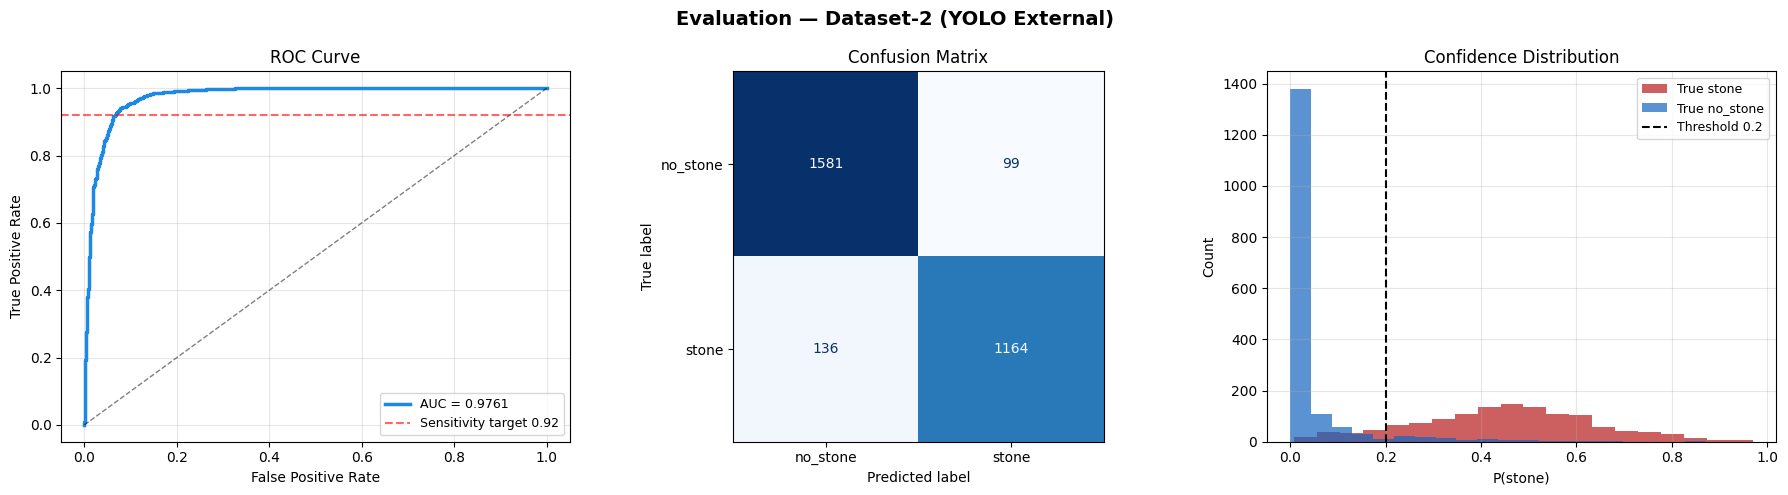

In [15]:
fig = plt.figure(figsize=(18, 5))
gs  = gridspec.GridSpec(1, 3, figure=fig)
fig.suptitle(f'Evaluation — {DATASET_NAME}', fontsize=14, fontweight='bold')

# ── Plot 1: ROC Curve ─────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0])
if has_both_classes:
    fpr, tpr, _ = roc_curve(all_labels, all_probs)
    ax1.plot(fpr, tpr, color='#1E88E5', lw=2.5, label=f'AUC = {auc:.4f}')
    ax1.plot([0,1],[0,1],'k--', lw=1, alpha=0.5)
    ax1.axhline(0.92, color='red', linestyle='--', alpha=0.6, label='Sensitivity target 0.92')
    ax1.set_xlabel('False Positive Rate')
    ax1.set_ylabel('True Positive Rate')
    ax1.set_title('ROC Curve')
    ax1.legend(fontsize=9)
    ax1.grid(alpha=0.3)
else:
    ax1.text(0.5, 0.5, 'ROC N/A\n(single class)', ha='center', va='center',
             transform=ax1.transAxes, fontsize=12, color='gray')
    ax1.set_title('ROC Curve')

# ── Plot 2: Confusion Matrix ──────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1])
if has_both_classes:
    cm = confusion_matrix(all_labels, all_preds)
    ConfusionMatrixDisplay(cm, display_labels=['no_stone','stone']).plot(
        ax=ax2, colorbar=False, cmap='Blues')
    ax2.set_title('Confusion Matrix')
else:
    ax2.bar(['TP (correct)', 'FN (missed)'], [tp, fn],
            color=['#2E7D32','#B71C1C'])
    ax2.set_title(f'Stone Detection\nSensitivity = {sensitivity:.4f}')
    ax2.set_ylabel('Count')
    for i, v in enumerate([tp, fn]):
        ax2.text(i, v + 1, str(v), ha='center', fontweight='bold')

# ── Plot 3: Confidence Distribution ──────────────────────────────────────────
ax3 = fig.add_subplot(gs[2])
if has_both_classes:
    ax3.hist(all_probs[all_labels==1], bins=20, alpha=0.7,
             color='#B71C1C', label='True stone')
    ax3.hist(all_probs[all_labels==0], bins=20, alpha=0.7,
             color='#1565C0', label='True no_stone')
    ax3.legend(fontsize=9)
else:
    ax3.hist(all_probs, bins=20, color='#B71C1C', alpha=0.8)
ax3.axvline(THRESHOLD, color='black', linestyle='--', lw=1.5,
            label=f'Threshold {THRESHOLD}')
ax3.set_xlabel('P(stone)')
ax3.set_ylabel('Count')
ax3.set_title('Confidence Distribution')
ax3.legend(fontsize=9)
ax3.grid(alpha=0.3)

plt.tight_layout()
if SAVE_RESULTS:
    save_path = f'reports/eval_{DATASET_NAME.replace(" ","_").replace("(","").replace(")","")}.png'
    plt.savefig(save_path, dpi=120, bbox_inches='tight')
    print(f'Saved to {save_path}')
plt.show()

## Cell 8 — Show Hardest Cases (Low Confidence Correct + Wrong Predictions)

False Negatives (missed stones): 136
False Positives (false alarms):  99
Low confidence correct (0.4–0.6): 546


/var/folders/j6/pzqtnpsn3jg_xgp4jg2_w4bc0000gn/T/ipykernel_57100/292688512.py:35: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from current font.
  plt.tight_layout()
/Users/devaguru/Kidney Stone CNN/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


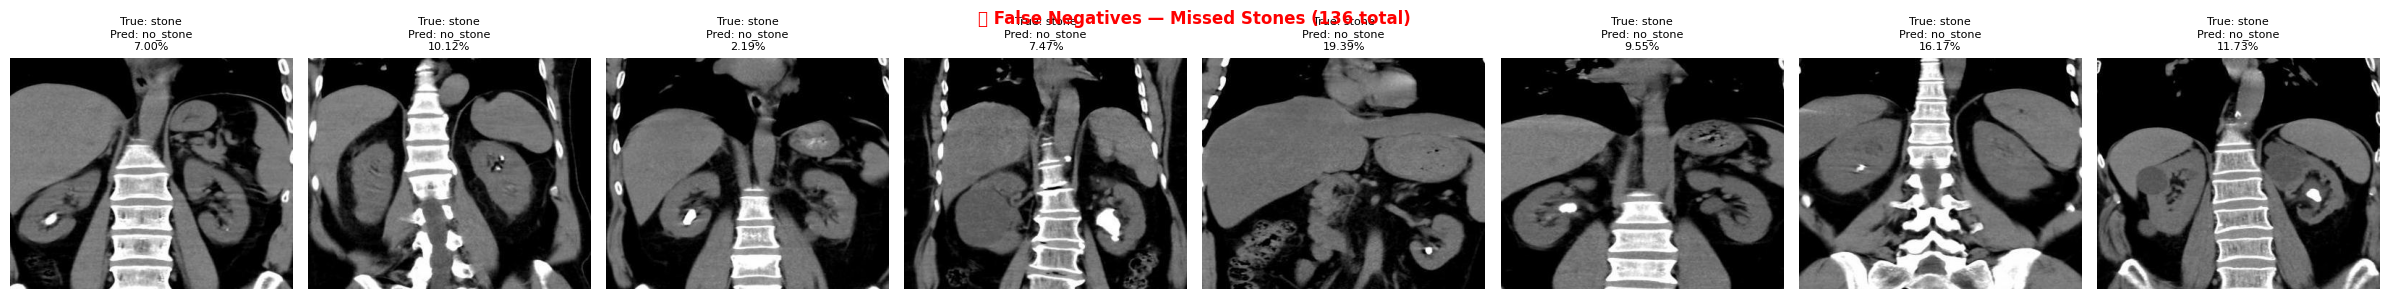

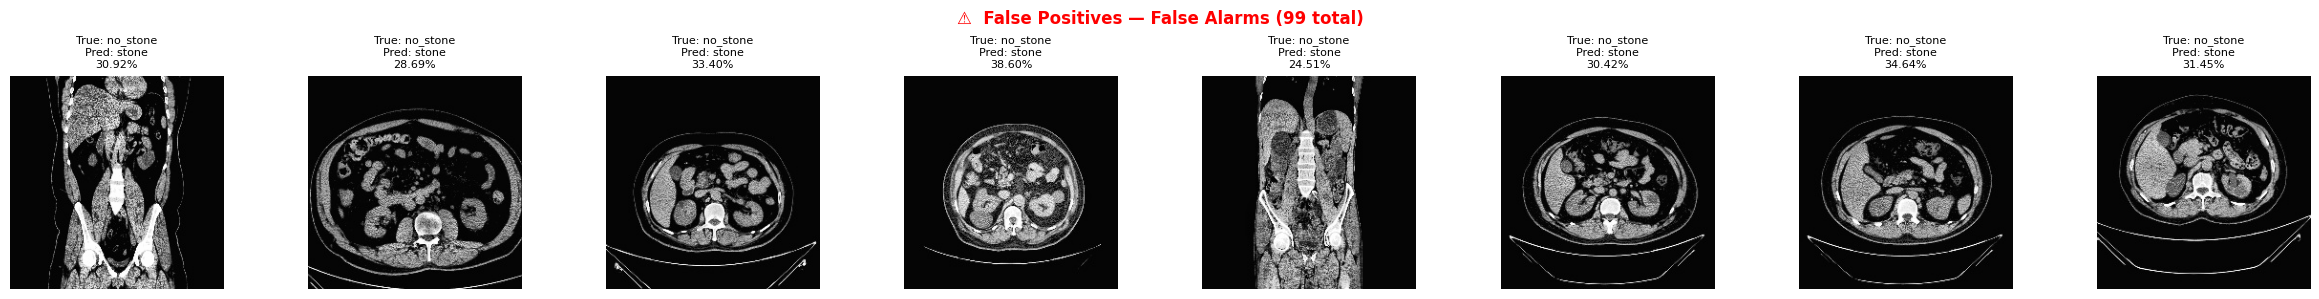

/var/folders/j6/pzqtnpsn3jg_xgp4jg2_w4bc0000gn/T/ipykernel_57100/292688512.py:35: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from current font.
  plt.tight_layout()
/Users/devaguru/Kidney Stone CNN/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


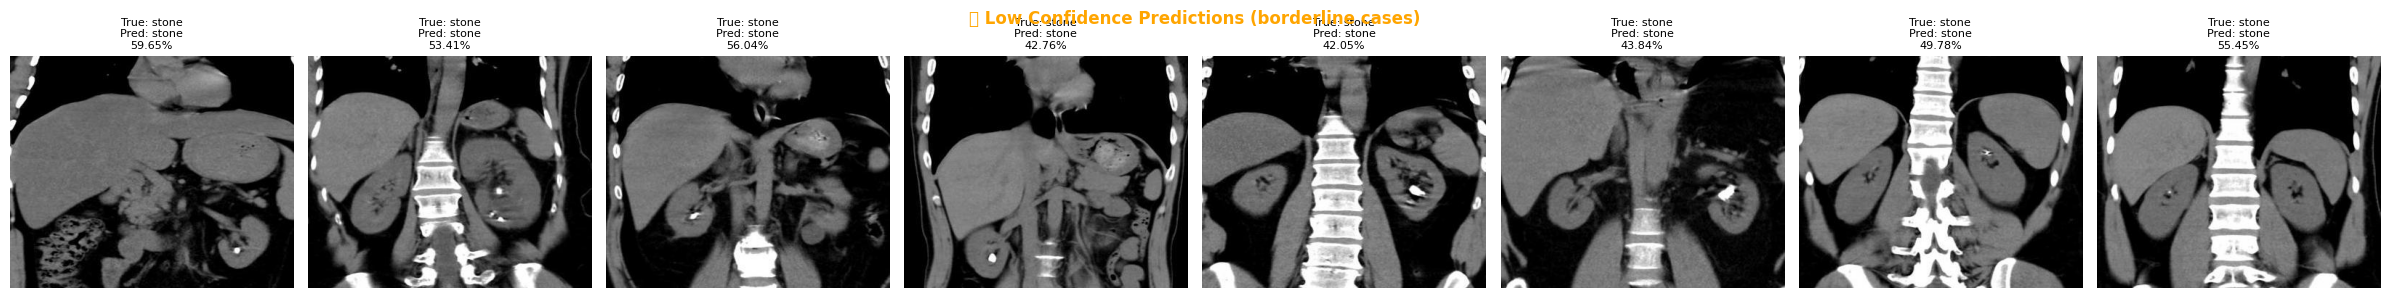

In [16]:
results_df = pd.DataFrame({
    'path':       all_paths,
    'true_label': all_labels,
    'pred':       all_preds,
    'prob_stone': all_probs,
    'correct':    all_labels == all_preds
})

false_neg = results_df[(results_df.true_label==1) & (results_df.pred==0)]
false_pos = results_df[(results_df.true_label==0) & (results_df.pred==1)]
low_conf  = results_df[results_df.correct & (results_df.prob_stone.between(0.4, 0.6))]

print(f'False Negatives (missed stones): {len(false_neg)}')
print(f'False Positives (false alarms):  {len(false_pos)}')
print(f'Low confidence correct (0.4–0.6): {len(low_conf)}')

def show_images(subset, title, max_show=8):
    if len(subset) == 0:
        print(f'No {title} to show.')
        return
    subset = subset.head(max_show)
    n = len(subset)
    fig, axes = plt.subplots(1, n, figsize=(n*3, 3))
    if n == 1: axes = [axes]
    fig.suptitle(title, fontsize=12, fontweight='bold',
                 color='red' if 'False' in title else 'orange')
    for ax, (_, row) in zip(axes, subset.iterrows()):
        img = cv2.cvtColor(cv2.imread(row.path), cv2.COLOR_BGR2RGB)
        ax.imshow(img)
        true_name = 'stone' if row.true_label==1 else 'no_stone'
        pred_name = 'stone' if row.pred==1 else 'no_stone'
        ax.set_title(f'True: {true_name}\nPred: {pred_name}\n{row.prob_stone:.2%}',
                     fontsize=8)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

show_images(false_neg, f'❌ False Negatives — Missed Stones ({len(false_neg)} total)')
show_images(false_pos, f'⚠️  False Positives — False Alarms ({len(false_pos)} total)')
show_images(low_conf,  f'🟡 Low Confidence Predictions (borderline cases)')

## Cell 9 — Full Results Table

In [17]:
results_df['filename']   = results_df.path.apply(lambda x: Path(x).name)
results_df['true_class'] = results_df.true_label.map({1:'stone', 0:'no_stone'})
results_df['pred_class'] = results_df.pred.map({1:'stone', 0:'no_stone'})
results_df['result']     = results_df.correct.map({True:'✅ Correct', False:'❌ Wrong'})

display_df = results_df[['filename','true_class','pred_class','prob_stone','result']].copy()
display_df['prob_stone'] = display_df['prob_stone'].round(4)
display_df = display_df.sort_values('prob_stone', ascending=False)

# Show wrong predictions first
wrong = display_df[display_df.result == '❌ Wrong']
print(f'Wrong predictions: {len(wrong)}')
if len(wrong) > 0:
    display(wrong.head(20))

print(f'\nAll results ({len(display_df)} images):')
display(display_df.head(30))

if SAVE_RESULTS:
    csv_path = f'reports/eval_{DATASET_NAME.replace(" ","_").replace("(","").replace(")","")}.csv'
    results_df.to_csv(csv_path, index=False)
    print(f'Full results saved to {csv_path}')

Wrong predictions: 235


,filename,true_class,pred_class,prob_stone,result
1597,Cyst- (685).jpg,no_stone,stone,0.8708,❌ Wrong
2807,Cyst- (691).jpg,no_stone,stone,0.6700,❌ Wrong
2184,Cyst- (2490).jpg,no_stone,stone,0.6417,❌ Wrong
2135,Cyst- (2368).jpg,no_stone,stone,0.6173,❌ Wrong
1890,Cyst- (3688).jpg,no_stone,stone,0.6078,❌ Wrong
1621,Normal- (3949).jpg,no_stone,stone,0.5753,❌ Wrong
1661,Normal- (3119).jpg,no_stone,stone,0.5615,❌ Wrong
1870,Cyst- (270).jpg,no_stone,stone,0.5537,❌ Wrong
2525,Cyst- (3687).jpg,no_stone,stone,0.5262,❌ Wrong
2607,Cyst- (3634).jpg,no_stone,stone,0.5249,❌ Wrong



All results (2980 images):


,filename,true_class,pred_class,prob_stone,result
285,1-3-46-670589-33-1-63709251749706939100001-532...,stone,stone,0.9688,✅ Correct
891,1-3-46-670589-33-1-63737838021524892400001-549...,stone,stone,0.9617,✅ Correct
776,1-3-46-670589-33-1-63724359033362545300001-491...,stone,stone,0.9567,✅ Correct
30,1-3-46-670589-33-1-63738190974140792500001-472...,stone,stone,0.9475,✅ Correct
950,1-3-46-670589-33-1-63712351712002604700001-565...,stone,stone,0.9231,✅ Correct
1195,1-3-46-670589-33-1-63737838021524892400001-549...,stone,stone,0.9070,✅ Correct
112,1-3-46-670589-33-1-63738356146609408000001-571...,stone,stone,0.9005,✅ Correct
815,1-3-46-670589-33-1-63712351712002604700001-565...,stone,stone,0.8989,✅ Correct
991,1-3-46-670589-33-1-63727467344282839400001-541...,stone,stone,0.8879,✅ Correct
142,1-3-46-670589-33-1-63741467279613397800001-538...,stone,stone,0.8830,✅ Correct


Full results saved to reports/eval_Dataset-2_YOLO_External.csv
